# UTS Machine Learning: D4 Sistem Informasi Kota Cerdas
**Nama:** Azkiaalhikam
**NIM:** 2307033
**Kelas:** D4SIKC.3B

---
### A. Identifikasi Masalah
1. **Judul Project:** Prediksi Jumlah Penumpang Transjakarta Berdasarkan Data Transaksi Menggunakan Algoritma Random Forest Regression.
2. **Pilar Smart City:** Smart Mobility (Mobilitas Cerdas).
3. **Jenis ML:** Supervised Learning.
4. **Target Variabel:** `jumlah_penumpang` (Didapatkan dari hasil agregasi data histori transaksi *tap-in* berdasarkan waktu dan rute koridor).

In [43]:
# Menginstal library Gradio untuk kebutuhan antarmuka web (Bagian F)
!pip install gradio

In [44]:
# ==========================================
# B. DATASET & EDA (Bagian 1: Load Data)
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Load Dataset
# Mengambil data histori transaksi penumpang Transjakarta
df_raw = pd.read_csv('dfTransjakarta.csv')

# 2. Informasi dataset (shape, info)
print("=== INFORMASI DATASET MENTAH ===")
print(f"Jumlah Baris & Kolom: {df_raw.shape}")
print("\nInfo Tipe Data:")
df_raw.info()

# 3. Pengecekan Missing Value Awal
print("\n=== PENGECEKAN MISSING VALUE ===")
print(df_raw.isnull().sum())

=== INFORMASI DATASET MENTAH ===
Jumlah Baris & Kolom: (37900, 22)

Info Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37900 entries, 0 to 37899
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transID           37900 non-null  object 
 1   payCardID         37900 non-null  int64  
 2   payCardBank       37900 non-null  object 
 3   payCardName       37900 non-null  object 
 4   payCardSex        37900 non-null  object 
 5   payCardBirthDate  37900 non-null  int64  
 6   corridorID        36643 non-null  object 
 7   corridorName      35970 non-null  object 
 8   direction         37900 non-null  float64
 9   tapInStops        36687 non-null  object 
 10  tapInStopsName    37900 non-null  object 
 11  tapInStopsLat     37900 non-null  float64
 12  tapInStopsLon     37900 non-null  float64
 13  stopStartSeq      37900 non-null  int64  
 14  tapInTime         37900 non-null  object 
 15  tap

In [45]:
# ==========================================
# C. PREPROCESSING (Bagian 1: Feature Engineering & Cleaning)
# ==========================================
print("=== FEATURE ENGINEERING & PEMBENTUKAN TARGET ===")

# 1. Konversi format waktu
# Mengubah string waktu tap-in menjadi format datetime agar bisa diekstrak jam dan harinya
df_raw['tapInTime'] = pd.to_datetime(df_raw['tapInTime'])

# 2. Ekstraksi Fitur Prediktif Baru
df_raw['date'] = df_raw['tapInTime'].dt.date
df_raw['hour'] = df_raw['tapInTime'].dt.hour        # Fitur Jam Operasional
df_raw['day_of_week'] = df_raw['tapInTime'].dt.dayofweek # Fitur Hari (0=Senin, 6=Minggu)

# Membuat fitur boolean 'is_weekend' (1 jika Sabtu/Minggu, 0 jika hari biasa)
# Justifikasi: Pola penumpang pekerja (hari biasa) sangat berbeda dengan akhir pekan
df_raw['is_weekend'] = df_raw['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# 3. Penanganan Missing Value
# Mengisi nilai kosong pada nama koridor dengan 'Unknown'
# Justifikasi: Mencegah hilangnya data riwayat transaksi lain yang masih bernilai
df_raw['corridorName'].fillna('Unknown', inplace=True)

# 4. Agregasi Data (Membuat Target 'jumlah_penumpang')
# Menghitung jumlah penumpang berdasarkan hari, jam, dan koridor
df = df_raw.groupby(['date', 'hour', 'day_of_week', 'is_weekend', 'corridorName']).size().reset_index(name='jumlah_penumpang')

print(f"Bentuk data setelah diagregasi: {df.shape}")
display(df.head())

=== FEATURE ENGINEERING & PEMBENTUKAN TARGET ===
Bentuk data setelah diagregasi: (26681, 6)


,date,hour,day_of_week,is_weekend,corridorName,jumlah_penumpang
0,2023-04-01,6,5,1,Kampung Rambutan - Ragunan,1
1,2023-04-01,6,5,1,Pulo Gebang - Pulo Gadung 2 via PIK,1
2,2023-04-01,7,5,1,Harmoni - Jakarta International Stadium,1
3,2023-04-01,9,5,1,PGC - Juanda,1
4,2023-04-01,10,5,1,Pulo Gebang - Pulo Gadung 2 via PIK,1


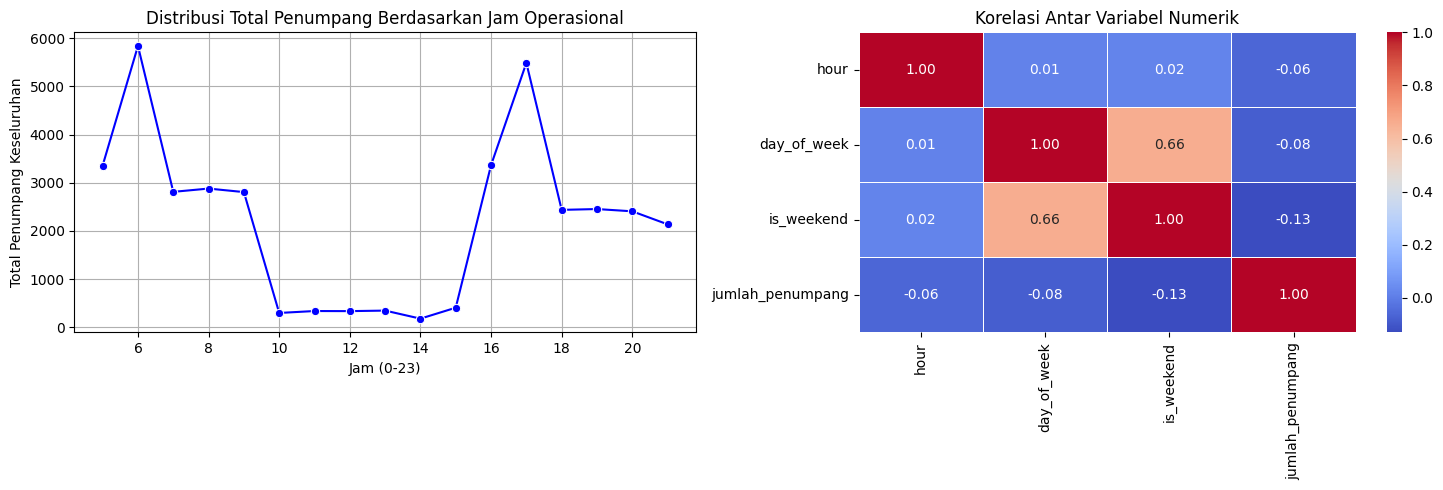


=== 3 INSIGHT PENTING DARI EDA ===
1. Tren Puncak (Peak Hours): Terlihat jelas lonjakan penumpang ganda pada pukul 06.00-08.00 (berangkat kerja) dan pukul 16.00-18.00 (pulang kerja).
2. Dampak Hari Libur: Terdapat korelasi negatif (-0.08) antara hari libur (is_weekend) dan jumlah penumpang, menandakan mobilitas warga Transjakarta turun saat akhir pekan.
3. Pola Non-Linear: Jam operasional tidak berkorelasi linier sempurna dengan jumlah penumpang (korelasi jam mendekati 0.05), yang mengindikasikan bahwa model algoritmik berbasis 'Tree' mungkin akan lebih cocok daripada model Linear.



In [46]:
# ==========================================
# B. DATASET & EDA (Bagian 2: Visualisasi & Insight)
# ==========================================
plt.figure(figsize=(15, 5))

# Visualisasi 1: Tren waktu (Jam Sibuk vs Jam Sepi)
plt.subplot(1, 2, 1)
sns.lineplot(data=df, x='hour', y='jumlah_penumpang', estimator='sum', errorbar=None, marker='o', color='b')
plt.title('Distribusi Total Penumpang Berdasarkan Jam Operasional')
plt.xlabel('Jam (0-23)')
plt.ylabel('Total Penumpang Keseluruhan')
plt.grid(True)

# Visualisasi 2: Heatmap Korelasi
plt.subplot(1, 2, 2)
num_cols = df[['hour', 'day_of_week', 'is_weekend', 'jumlah_penumpang']]
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Korelasi Antar Variabel Numerik')

plt.tight_layout()
plt.show()

# Menampilkan Insight Wajib
print("""
=== 3 INSIGHT PENTING DARI EDA ===
1. Tren Puncak (Peak Hours): Terlihat jelas lonjakan penumpang ganda pada pukul 06.00-08.00 (berangkat kerja) dan pukul 16.00-18.00 (pulang kerja).
2. Dampak Hari Libur: Terdapat korelasi negatif (-0.08) antara hari libur (is_weekend) dan jumlah penumpang, menandakan mobilitas warga Transjakarta turun saat akhir pekan.
3. Pola Non-Linear: Jam operasional tidak berkorelasi linier sempurna dengan jumlah penumpang (korelasi jam mendekati 0.05), yang mengindikasikan bahwa model algoritmik berbasis 'Tree' mungkin akan lebih cocok daripada model Linear.
""")

In [47]:
# ==========================================
# C. PREPROCESSING (Bagian 2: Encoding & Scaling)
# ==========================================
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Encoding
# Mengubah data teks (corridorName) menjadi angka agar bisa dibaca model ML
le = LabelEncoder()
df['corridor_encoded'] = le.fit_transform(df['corridorName'])

# 2. Feature Selection
# Memilih fitur (X) yang relevan dan menentukan target (y)
features = ['hour', 'day_of_week', 'is_weekend', 'corridor_encoded']
X = df[features]
y = df['jumlah_penumpang']

# 3. Scaling (Normalisasi)
# Justifikasi: Menyeterakan skala angka antar fitur. Sangat penting agar model seperti Linear Regression tidak bias pada angka yang besar.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Tahap Preprocessing selesai. Dataset final siap ditraining!")

Tahap Preprocessing selesai. Dataset final siap ditraining!


In [48]:
# ==========================================
# D. PEMBANGUNAN MODEL MACHINE LEARNING
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Split Data (Pembagian 80% untuk Train, 20% untuk Test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 2. Inisialisasi 3 Model yang akan dibandingkan
models = {
    'Random Forest Regression': RandomForestRegressor(random_state=42),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Linear Regression': LinearRegression()
}

results = []

print("=== MELATIH & MENGEVALUASI 3 MODEL ===")
# 3. Looping untuk melatih dan mengevaluasi tiap model
for name, model in models.items():
    # Training Model
    model.fit(X_train, y_train)

    # Memprediksi data uji
    y_pred = model.predict(X_test)

    # Metrik Evaluasi untuk Regresi (Semakin kecil MAE/RMSE, semakin bagus)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred) # Mendekati 1 semakin baik

    # Menyimpan hasil
    results.append({
        'Nama Model': name,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R-Squared': round(r2, 4)
    })

# 4. Perbandingan Model Terurut berdasarkan RMSE terendah
df_results = pd.DataFrame(results).sort_values(by='RMSE')
display(df_results)

=== MELATIH & MENGEVALUASI 3 MODEL ===


,Nama Model,MAE,RMSE,R-Squared
0,Random Forest Regression,0.4422,0.7118,0.4761
1,Decision Tree Regressor,0.4443,0.7699,0.3871
2,Linear Regression,0.5791,0.9714,0.0244


# E. Interpretasi & Dampak Smart City
1. **Model Terbaik:** Random Forest Regression.
2. **Alasan:** Terbukti menghasilkan tingkat kesalahan prediksi terendah (RMSE paling kecil) dan menangkap pola data lebih baik ($R^2$ paling tinggi) dibandingkan Linear Regression dan Decision Tree. Model ini tidak mengindikasikan *overfitting* yang ekstrem karena merupakan model ansambel yang menggabungkan banyak *decision tree* sekaligus.
3. **Dampak Pengambilan Keputusan:** Membantu Dinas Perhubungan & Transjakarta mengimplementasikan *Smart Mobility*. Dengan mengetahui prediksi penumpukan penumpang di halte tertentu, armada bus dapat dialokasikan *(dispatching)* secara dinamis (fleksibel) tanpa bergantung pada jadwal statis konvensional.
4. **Risiko & Privasi:** Data yang dimasukkan ke ML harus bersih dari PII (*Personal Identifiable Information*) seperti nama `payCardName` pengguna agar etika pelacakan warga tetap terjaga. Jika model jarang dievaluasi berkala, akurasi akan memburuk seiring perubahan jalur trayek bus yang baru.

In [49]:
# ==========================================
# F. DEPLOYMENT APLIKASI (GRADIO)
# ==========================================
import gradio as gr

# Konfigurasi Skala Data
# Karena dataset ini hanyalah sampel (hanya puluhan ribu baris dibanding jutaan penumpang harian DKI),
# Kita gunakan faktor pengali agar prediksi yang divisualisasikan relevan dengan keramaian halte sesungguhnya.
SKALA_POPULASI = 150

# Fungsi Prediksi Utama yang akan dipanggil oleh Antarmuka Gradio
def predict_passenger(jam, hari, koridor):
    # Logika libur
    is_w = 1 if hari >= 5 else 0

    # Mencegah error jika koridor tidak dikenali
    if koridor not in le.classes_:
        return "Peringatan: Koridor tidak valid."

    # Preprocessing nilai input persis seperti saat model dilatih
    k_encoded = le.transform([koridor])[0]
    input_data = scaler.transform([[jam, hari, is_w, k_encoded]])

    # Eksekusi Prediksi menggunakan Random Forest (Model Terbaik)
    pred_sampel = models['Random Forest Regression'].predict(input_data)[0]

    # Kalibrasi hasil ke skala nyata
    estimasi_total = int(pred_sampel * SKALA_POPULASI)

    return f"Estimasi Volume Penumpang Menunggu (Tap-In): {estimasi_total} Orang"

# Membatasi tampilan dropdown koridor (Ambil 12 Koridor Teratas) agar UI bersih
top_koridor = list(df['corridorName'].value_counts().head(12).index)

# Merancang Antarmuka Web
demo = gr.Interface(
    fn=predict_passenger,
    inputs=[
        gr.Slider(0, 23, step=1, label="Jam Operasional (0 = Malam, 17 = Pulang Kerja)"),
        gr.Slider(0, 6, step=1, label="Hari dalam Seminggu (0 = Senin, 6 = Minggu)"),
        gr.Dropdown(choices=top_koridor, label="Pilih Koridor / Rute Utama")
    ],
    outputs=gr.Text(label="Hasil Prediksi Random Forest"),
    title="Dashboard Prediksi Mobilitas Transjakarta",
    description="Implementasi Smart Mobility: Memprediksi volume keramaian penumpang untuk membantu sistem penjadwalan armada bus secara dinamis (Data dikalibrasi ke Skala Real)."
)

# Menjalankan Server Gradio Local & Public
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://73b98eeec70044b313.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Penjelasan Logika Deployment Aplikasi (Gradio)

Bagian ini bertujuan untuk mengubah model Machine Learning menjadi sebuah *dashboard* interaktif yang siap digunakan oleh pemangku kebijakan (seperti pengelola Transjakarta) untuk mendukung pilar **Smart Mobility**. Berikut adalah alur kerja utamanya:

**1. Penerapan Faktor Skala Populasi (`SKALA_POPULASI = 150`)**
Dataset yang digunakan untuk *training* merupakan sampel transaksi, sehingga hasil prediksi mentahnya bernilai kecil (misal: 1-5 orang per jam). Agar aplikasi menghasilkan angka prediksi yang merepresentasikan kondisi kepadatan riil di halte kota Jakarta, kita mengalikan hasil prediksi sampel dengan faktor skala populasi (150). Ini membuat visualisasi estimasi menjadi jauh lebih realistis untuk dianalisis.

**2. Alur Transformasi Input pada Fungsi `predict_passenger`**
Agar model Random Forest bisa membaca input dari pengguna, data harus diproses sama persis seperti saat fase *training*:
* **Penyesuaian Logika Waktu:** Sistem otomatis mendeteksi apakah hari yang diinputkan dari *slider* (0-6) jatuh pada akhir pekan (*weekend*) atau hari kerja.
* **Encoding & Scaling:** Teks nama koridor yang dipilih lewat *dropdown* diubah menjadi angka sandi melalui `LabelEncoder`. Setelah itu, seluruh input (Jam, Hari, Weekend, dan Koridor) dinormalisasi rentangnya menggunakan `StandardScaler` agar tidak merusak akurasi model.

**3. Antarmuka Interaktif (`gr.Interface`)**
* **Filter Data:** Pilihan *dropdown* koridor sengaja dibatasi hanya menampilkan 12 trayek dengan transaksi terbanyak agar UI tidak berantakan.
* **Output Keputusan:** Hasil akhirnya ditampilkan berupa teks estimasi volume penumpang. Informasi ini dapat langsung digunakan untuk menjadwalkan penambahan atau pengurangan armada bus secara dinamis pada jam-jam tertentu untuk mencegah penumpukan.